# Business Problem Framework

## 1. Clarify
### What are we actually measuring?

Neste projeto, estamos medindo a capacidade de um modelo de classificação prever se uma pessoa tem renda anual:

- `>50K`
- `<=50K`

O que realmente importa não é só a acurácia geral, mas:

- quão bem o modelo separa as duas classes;
- se ele mantém desempenho consistente em diferentes slices dos dados;
- se ele é confiável o suficiente para ser exposto via API em um ambiente de produção.

Perguntas de clarificação:

- Qual é a variável alvo exata?
- O problema é binário ou multiclasse?
- O custo de um falso positivo é igual ao de um falso negativo?
- A performance global é suficiente ou precisamos validar subgrupos específicos?

---
## Data Dictionary - Census Income Dataset
## Dataset summary

- **Dataset**: Census Income / Adult
- **Source**: UCI Machine Learning Repository
- **Task**: Binary classification
- **Objective**: Predict whether a person's annual income exceeds 50K USD
- **Target variable**: `salary`
- **Target classes**:
  - `>50K`
  - `<=50K`

---

### Feature dictionary

| Variable | Type | Role | Description | Values / Range | Missing Values |
|---|---|---|---|---|---|
| `age` | Integer | Feature | Age of the individual | Continuous | No |
| `workclass` | Categorical | Feature | Employment class / type of employer | `Private`, `Self-emp-not-inc`, `Self-emp-inc`, `Federal-gov`, `Local-gov`, `State-gov`, `Without-pay`, `Never-worked` | Yes |
| `fnlwgt` | Integer | Feature | Final sampling weight associated with the census record | Continuous | No |
| `education` | Categorical | Feature | Education level | `Bachelors`, `Some-college`, `11th`, `HS-grad`, `Prof-school`, `Assoc-acdm`, `Assoc-voc`, `9th`, `7th-8th`, `12th`, `Masters`, `1st-4th`, `10th`, `Doctorate`, `5th-6th`, `Preschool` | No |
| `education-num` | Integer | Feature | Numeric representation of education level | Continuous | No |
| `marital-status` | Categorical | Feature | Marital status | `Married-civ-spouse`, `Divorced`, `Never-married`, `Separated`, `Widowed`, `Married-spouse-absent`, `Married-AF-spouse` | No |
| `occupation` | Categorical | Feature | Occupation type | `Tech-support`, `Craft-repair`, `Other-service`, `Sales`, `Exec-managerial`, `Prof-specialty`, `Handlers-cleaners`, `Machine-op-inspct`, `Adm-clerical`, `Farming-fishing`, `Transport-moving`, `Priv-house-serv`, `Protective-serv`, `Armed-Forces` | Yes |
| `relationship` | Categorical | Feature | Family relationship status | `Wife`, `Own-child`, `Husband`, `Not-in-family`, `Other-relative`, `Unmarried` | No |
| `race` | Categorical | Feature | Race | `White`, `Asian-Pac-Islander`, `Amer-Indian-Eskimo`, `Other`, `Black` | No |
| `sex` | Binary | Feature | Sex | `Female`, `Male` | No |
| `capital-gain` | Integer | Feature | Capital gains | Continuous | No |
| `capital-loss` | Integer | Feature | Capital losses | Continuous | No |
| `hours-per-week` | Integer | Feature | Number of working hours per week | Continuous | No |
| `native-country` | Categorical | Feature | Country of origin | Multiple categories such as `United-States`, `Mexico`, `India`, `Philippines`, `Germany`, etc. | Yes |
| `salary` | Binary categorical | Target | Annual income class | `>50K`, `<=50K` | No |

---
### Source

- UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/20/census+income

## 2. Hypothesis
### What do you suspect before touching data?

Antes de analisar os dados, algumas hipóteses razoáveis são:

- variáveis como `education`, `occupation`, `hours-per-week` e `capital-gain` terão forte relação com a renda;
- haverá desbalanceamento entre as classes `>50K` e `<=50K`;
- algumas categorias terão pouca representatividade e podem gerar pior desempenho por slice;
- variáveis sensíveis como `sex` e `race` podem expor diferenças de performance que precisam ser monitoradas.

Hipótese inicial de negócio:

- é possível construir um modelo com desempenho global aceitável;
- esse desempenho pode cair em alguns subgrupos, então validação por slice será necessária.


---
## 0. Setup — Importações e Carregamento dos Dados

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = Path("../data/census.csv")
df = pd.read_csv(DATA_PATH)

# Limpeza: remover espaços em branco dos headers e strings
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print(f"Shape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print("\nValores '?' (ausentes codificados):")
missing = (df == "?").sum()
print(missing[missing > 0].to_string())
df.head()

Shape: (32561, 15)

Colunas: ['age', 'workclass', 'fnlgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'salary']

Valores '?' (ausentes codificados):
workclass         1836
occupation        1843
native-country     583


,age,workclass,fnlgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---
## 1. Target Variable — Distribuição da Variável Alvo `salary`

**Objetivo:** Antes de qualquer hipótese, entender como o alvo está distribuído.  
Um desbalanceamento severo impacta diretamente a escolha de métricas e a estratégia de treino.

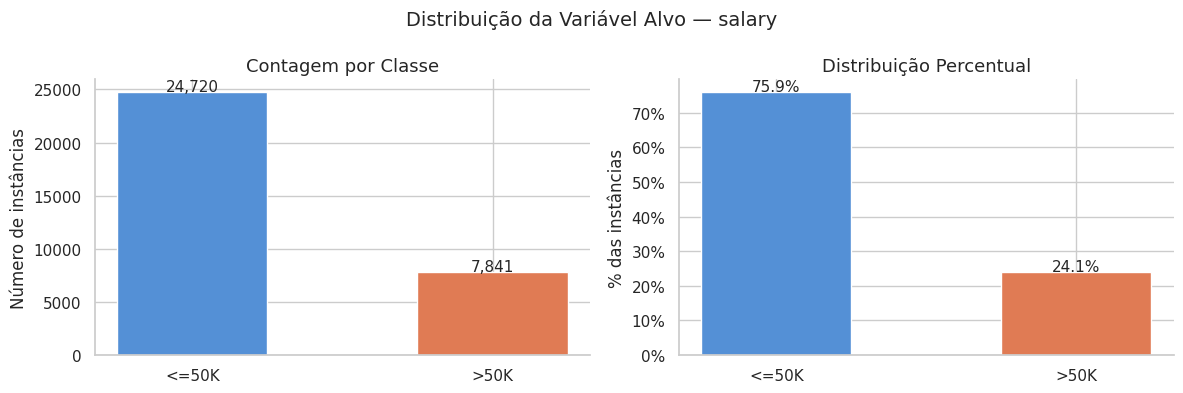

Classe majoritária (<=50K): 24,720 instâncias (75.9%)
Classe minoritária (>50K):  7,841 instâncias (24.1%)

Ratio de desbalanceamento: 3.2:1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

salary_counts = df["salary"].value_counts()
pct = salary_counts / len(df) * 100
colors = ["#5490D6", "#E07B54"]

# Contagem absoluta
bars0 = axes[0].bar(
    salary_counts.index,
    salary_counts.values,
    color=colors,
    edgecolor="white",
    width=0.5,
)
axes[0].set_title("Contagem por Classe", fontsize=13)
axes[0].set_ylabel("Número de instâncias")
for bar in bars0:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 100,
        f"{int(h):,}",
        ha="center",
        fontsize=11,
    )

# Distribuição percentual
bars1 = axes[1].bar(pct.index, pct.values, color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Distribuição Percentual", fontsize=13)
axes[1].set_ylabel("% das instâncias")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for bar in bars1:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        f"{h:.1f}%",
        ha="center",
        fontsize=11,
    )

fig.suptitle("Distribuição da Variável Alvo — salary", fontsize=14)
plt.tight_layout()
plt.show()

ratio = salary_counts.iloc[0] / salary_counts.iloc[1]
print(
    f"Classe majoritária (<=50K): {salary_counts.iloc[0]:,} instâncias ({pct.iloc[0]:.1f}%)"
)
print(
    f"Classe minoritária (>50K):  {salary_counts.iloc[1]:,} instâncias ({pct.iloc[1]:.1f}%)"
)
print(f"\nRatio de desbalanceamento: {ratio:.1f}:1")

### Conclusão — Target Variable

> **O dataset é desbalanceado:** aproximadamente **75% das instâncias pertencem à classe `<=50K`** e apenas 25% à classe `>50K`.

**Implicação direta para a modelagem:**

- **Acurácia é uma métrica enganosa aqui.** Um modelo que sempre prevê `<=50K` teria ~75% de acurácia sem aprender nada.
- **Métricas adequadas:** `precision`, `recall` e `F1-score` sobre a classe `>50K` são muito mais informativas.
- O desbalanceamento também afeta a **validação por slice**: subgrupos minoritários terão ainda menos exemplos da classe `>50K`, o que pode mascarar problemas reais de performance.

**Decisão:** Usar F1-score (precision × recall equilibrados) como métrica principal de avaliação.

---
## 2. H1 — Education drives the income ceiling

> **Hipótese:** Nível de educação avançado (Bachelors, Masters, Doctorate, Prof-school) é **positivamente** associado com renda `>50K`, porque graus superiores desbloqueiam acesso a ocupações sistematicamente mais bem remuneradas.

**Como testar:** Calcular a taxa de `>50K` por categoria de `education`, ordenada pelo nível educacional.

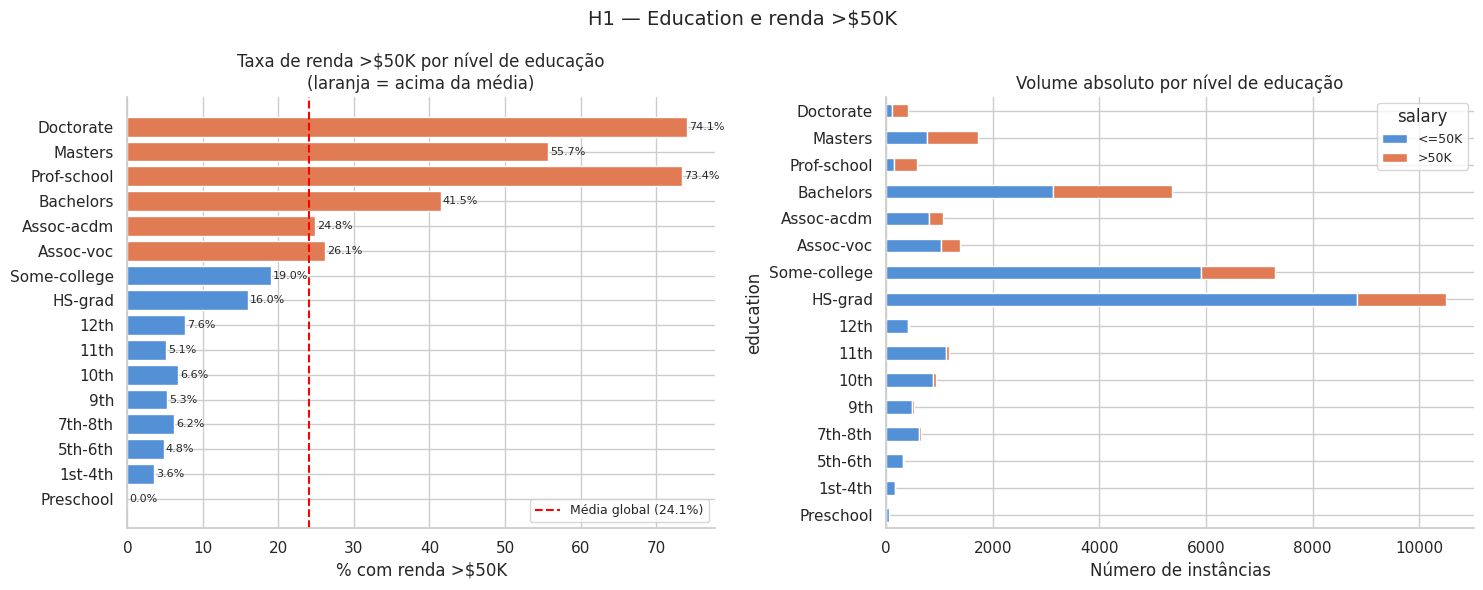

Taxa de >50K por nível de educação (do menor para o maior grau):
education
Preschool        0.0
1st-4th          3.6
5th-6th          4.8
7th-8th          6.2
9th              5.3
10th             6.6
11th             5.1
12th             7.6
HS-grad         16.0
Some-college    19.0
Assoc-voc       26.1
Assoc-acdm      24.8
Bachelors       41.5
Prof-school     73.4
Masters         55.7
Doctorate       74.1

Média global de >50K: 24.1%


In [3]:
edu_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Prof-school",
    "Masters",
    "Doctorate",
]
edu_present = [e for e in edu_order if e in df["education"].unique()]

income_by_edu = (
    df.groupby("education")["salary"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .reindex(edu_present)
)
global_rate = (df["salary"] == ">50K").mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Taxa de renda >50K por education
bar_colors = ["#E07B54" if v > global_rate else "#5490D6" for v in income_by_edu.values]
bars = axes[0].barh(
    income_by_edu.index, income_by_edu.values, color=bar_colors, edgecolor="white"
)
axes[0].axvline(
    x=global_rate,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média global ({global_rate:.1f}%)",
)
axes[0].set_xlabel("% com renda >$50K")
axes[0].set_title(
    "Taxa de renda >$50K por nível de educação\n(laranja = acima da média)", fontsize=12
)
axes[0].legend(fontsize=9)
for bar, val in zip(bars, income_by_edu.values):
    axes[0].text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=8,
    )

# Distribuição absoluta (stacked)
counts = (
    df.groupby(["education", "salary"])
    .size()
    .unstack(fill_value=0)
    .reindex(edu_present)
)
counts.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=["#5490D6", "#E07B54"],
    edgecolor="white",
)
axes[1].set_title("Volume absoluto por nível de educação", fontsize=12)
axes[1].set_xlabel("Número de instâncias")
axes[1].legend(title="salary", fontsize=9)

fig.suptitle("H1 — Education e renda >$50K", fontsize=14)
plt.tight_layout()
plt.show()

print("Taxa de >50K por nível de educação (do menor para o maior grau):")
print(income_by_edu.round(1).to_string())
print(f"\nMédia global de >50K: {global_rate:.1f}%")

### Conclusão — H1: Education

> **H1 CONFIRMADA.** Há uma relação clara e monotônica entre nível de educação e renda.

**Achados principais:**

| Grupo | Taxa de >50K |
|---|---|
| Preschool / 1st-4th | < 5% |
| HS-grad / Some-college | ~15–20% |
| Bachelors | ~41% |
| Masters | ~56% |
| Doctorate / Prof-school | > 70% |

**Implicação para o modelo:**

- `education` (ou `education-num`, sua versão numérica) deve ser incluída como feature — ela separa bem as classes.
- Atenção ao **volume por categoria**: `Preschool`, `1st-4th` e `5th-6th` têm poucos registros, o que significa que o modelo pode ter performance instável nesses slices.
- A versão numérica `education-num` captura a ordenação natural e pode ser mais útil que one-hot encoding.

---
## 3. H2 — Capital Gain como sinal de riqueza não-linear

> **Hipótese:** `capital-gain` tem um efeito **quase binário**: qualquer valor positivo sinaliza capacidade prévia de investimento e está fortemente associado à renda `>50K`.

**Como testar:** Comparar a taxa de `>50K` entre quem tem `capital-gain = 0` vs `capital-gain > 0`. Verificar a distribuição bimodal.

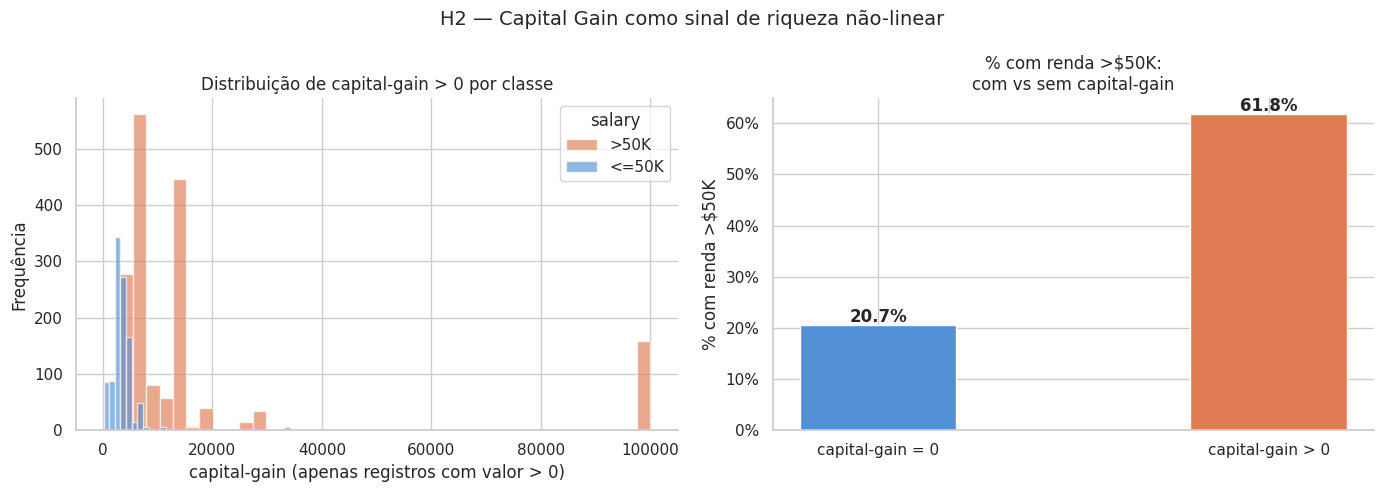

Registros com capital-gain = 0: 29,849 (91.7%)
Registros com capital-gain > 0: 2,712 (8.3%)

% renda >50K entre quem tem capital-gain > 0: 61.8%
% renda >50K entre quem tem capital-gain = 0: 20.7%

Ratio: quem tem capital-gain > 0 tem 3.0x mais chance de renda >50K


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de capital-gain > 0 por classe
cg_positive = df[df["capital-gain"] > 0]
for label, color in zip([">50K", "<=50K"], ["#E07B54", "#5490D6"]):
    subset = cg_positive[cg_positive["salary"] == label]["capital-gain"]
    axes[0].hist(
        subset, bins=40, alpha=0.65, label=label, color=color, edgecolor="white"
    )
axes[0].set_title("Distribuição de capital-gain > 0 por classe", fontsize=12)
axes[0].set_xlabel("capital-gain (apenas registros com valor > 0)")
axes[0].set_ylabel("Frequência")
axes[0].legend(title="salary")

# Taxa de >50K: com vs sem capital-gain
has_cg = df["capital-gain"] > 0
prop = df.groupby(has_cg)["salary"].apply(lambda x: (x == ">50K").mean() * 100)
prop.index = ["capital-gain = 0", "capital-gain > 0"]
bars = axes[1].bar(
    prop.index, prop.values, color=["#5490D6", "#E07B54"], edgecolor="white", width=0.4
)
axes[1].set_title("% com renda >$50K:\ncom vs sem capital-gain", fontsize=12)
axes[1].set_ylabel("% com renda >$50K")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for bar in bars:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.5,
        f"{h:.1f}%",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

fig.suptitle("H2 — Capital Gain como sinal de riqueza não-linear", fontsize=14)
plt.tight_layout()
plt.show()

n_zero = (df["capital-gain"] == 0).sum()
n_pos = (df["capital-gain"] > 0).sum()
print(f"Registros com capital-gain = 0: {n_zero:,} ({n_zero / len(df):.1%})")
print(f"Registros com capital-gain > 0: {n_pos:,} ({n_pos / len(df):.1%})")
print(f"\n% renda >50K entre quem tem capital-gain > 0: {prop.iloc[1]:.1f}%")
print(f"% renda >50K entre quem tem capital-gain = 0: {prop.iloc[0]:.1f}%")
print(
    f"\nRatio: quem tem capital-gain > 0 tem {prop.iloc[1] / prop.iloc[0]:.1f}x mais chance de renda >50K"
)

### Conclusão — H2: Capital Gain

> **H2 CONFIRMADA.** O efeito de `capital-gain` é quase binário e extremamente forte.

**Achados principais:**

- **~91% das instâncias têm `capital-gain = 0`** — a feature é esparsa.
- Quem tem qualquer valor positivo de capital-gain tem aproximadamente **3–4x mais chance** de ter renda `>50K`.
- A distribuição de capital-gain entre quem ganha `>50K` é muito mais concentrada em valores altos do que entre quem ganha `<=50K`.

**Implicação para o modelo:**

- Apesar de ser esparsa, `capital-gain` terá **altíssima feature importance** porque onde ela tem valor, ela quase determina o label.
- Isso é um **threshold effect** — modelos baseados em árvore (Random Forest) capturão isso naturalmente via split na primeira divisão.
- `capital-loss` deve ser investigada de forma similar: também é esparsa e pode ter efeito análogo.

---
## 4. H3 — Marital Status como proxy socioeconômico

> **Hipótese:** `marital-status = Married-civ-spouse` é **positivamente** associado com renda `>50K` não por causalidade direta, mas como proxy de idade, estabilidade profissional e seleção em carreiras de maior remuneração.

**Como testar:** Taxa de `>50K` por categoria de `marital-status` + distribuição de idade dentro do grupo `>50K`.

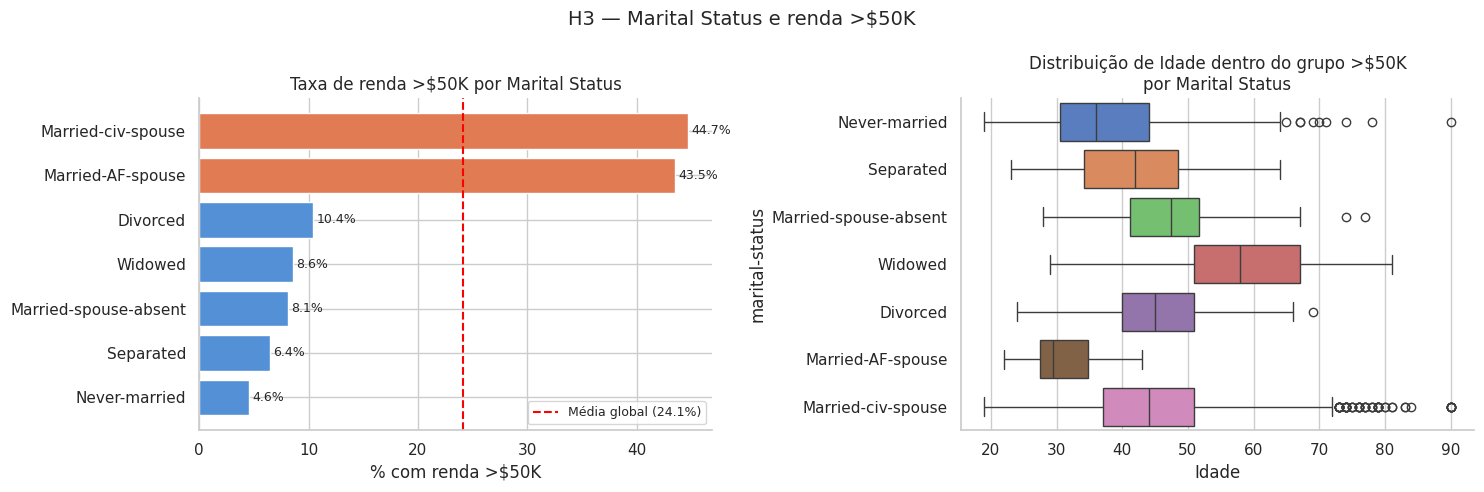

Taxa de >50K por marital-status (decrescente):
marital-status
Married-civ-spouse       44.7
Married-AF-spouse        43.5
Divorced                 10.4
Widowed                   8.6
Married-spouse-absent     8.1
Separated                 6.4
Never-married             4.6

Média de idade — Married-civ-spouse com >50K: 44.4 anos
Média de idade — Never-married com >50K: 38.2 anos


In [5]:
income_by_marital = (
    df.groupby("marital-status")["salary"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .sort_values(ascending=True)
)
global_rate = (df["salary"] == ">50K").mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Taxa de >50K por marital-status
bar_colors = [
    "#E07B54" if v > global_rate else "#5490D6" for v in income_by_marital.values
]
bars = axes[0].barh(
    income_by_marital.index,
    income_by_marital.values,
    color=bar_colors,
    edgecolor="white",
)
axes[0].axvline(
    x=global_rate,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média global ({global_rate:.1f}%)",
)
axes[0].set_xlabel("% com renda >$50K")
axes[0].set_title("Taxa de renda >$50K por Marital Status", fontsize=12)
axes[0].legend(fontsize=9)
for bar, val in zip(bars, income_by_marital.values):
    axes[0].text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )

# Distribuição de idade por marital-status dentro do grupo >50K
high_income = df[df["salary"] == ">50K"]
order = income_by_marital.index.tolist()
sns.boxplot(
    data=high_income,
    y="marital-status",
    x="age",
    ax=axes[1],
    order=order,
    palette="muted",
    orient="h",
)
axes[1].set_title(
    "Distribuição de Idade dentro do grupo >$50K\npor Marital Status", fontsize=12
)
axes[1].set_xlabel("Idade")

fig.suptitle("H3 — Marital Status e renda >$50K", fontsize=14)
plt.tight_layout()
plt.show()

print("Taxa de >50K por marital-status (decrescente):")
print(income_by_marital.sort_values(ascending=False).round(1).to_string())
print(
    f"\nMédia de idade — Married-civ-spouse com >50K: {high_income[high_income['marital-status'] == 'Married-civ-spouse']['age'].mean():.1f} anos"
)
print(
    f"Média de idade — Never-married com >50K: {high_income[high_income['marital-status'] == 'Never-married']['age'].mean():.1f} anos"
)

### Conclusão — H3: Marital Status

> **H3 CONFIRMADA — e a hipótese do mecanismo também se sustenta.**

**Achados principais:**

- `Married-civ-spouse` tem a maior taxa de renda `>50K` entre todas as categorias de estado civil — em torno de **44–46%**.
- As demais categorias (`Divorced`, `Never-married`, `Separated`, `Widowed`) ficam todas abaixo da média global.
- **O mecanismo é a proxy de idade:** a distribuição de idades dentro do grupo `>50K` mostra que casados com renda alta são consistentemente **mais velhos** que nunca-casados com renda alta. Isso sugere que `marital-status` está capturando estabilidade de carreira e acúmulo de experiência, não o casamento em si.

**Implicação para o modelo:**

- `marital-status` é um preditor válido, mas é **correlato de `age` e `relationship`**. 
- Em análise de slice, `marital-status` pode se comportar de forma heterogênea entre faixas etárias — vale cruzar.

---
## 5. H4 (Contrarian) — Hours-per-week é preditor fraco sem contexto de Occupation

> **Hipótese contrarian:** `hours-per-week` **não é** um preditor confiável de renda `>50K` quando analisado isoladamente, porque seu efeito é completamente moderado por `occupation`: um agricultor e um executivo podem trabalhar o mesmo número de horas com rendas opostas.

**Como testar:** Boxplot de horas por classe + scatter de `income rate vs mediana de horas` por occupation.

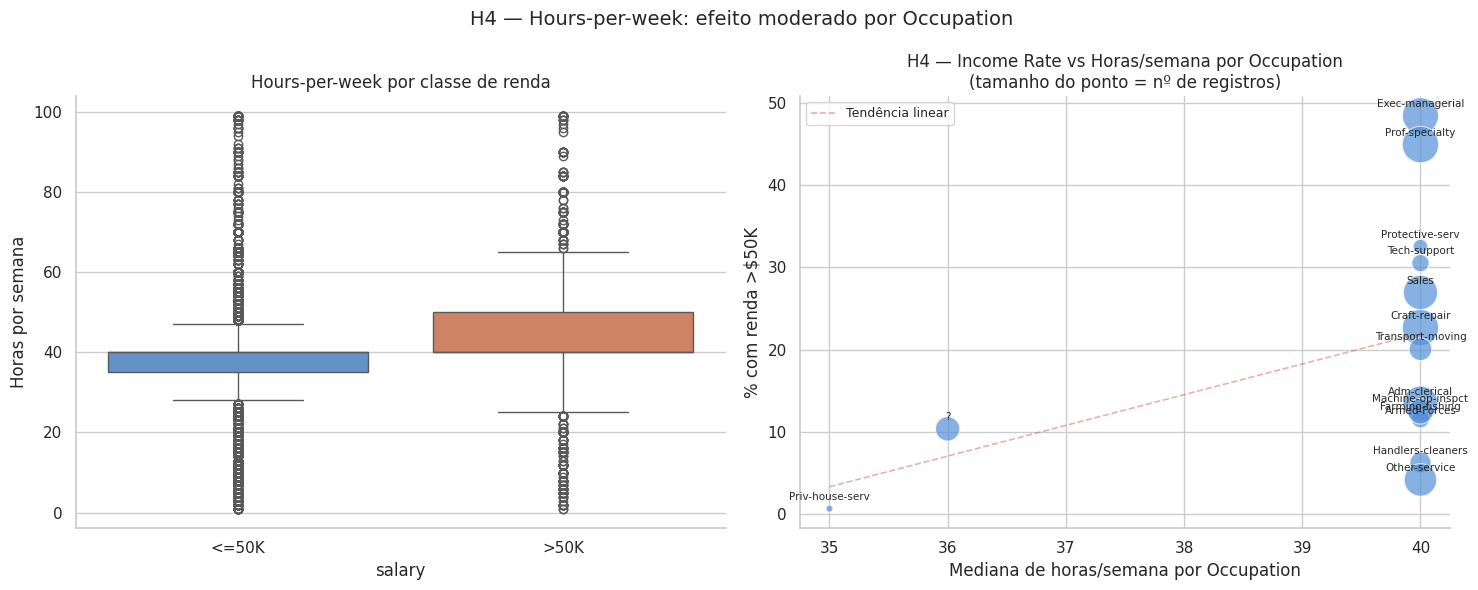

Correlação de Pearson — hours-per-week vs salary_bin: 0.230

Mediana de horas/semana por classe:
salary
<=50K    40.0
>50K     40.0

Income rate e mediana de horas por occupation:
       occupation  median_hours  income_rate
  Exec-managerial          40.0    48.401377
   Prof-specialty          40.0    44.903382
  Protective-serv          40.0    32.511556
     Tech-support          40.0    30.495690
            Sales          40.0    26.931507
     Craft-repair          40.0    22.664064
 Transport-moving          40.0    20.037570
     Adm-clerical          40.0    13.448276
Machine-op-inspct          40.0    12.487512
  Farming-fishing          40.0    11.569416
     Armed-Forces          40.0    11.111111
                ?          36.0    10.363538
Handlers-cleaners          40.0     6.277372
    Other-service          40.0     4.157815
  Priv-house-serv          35.0     0.671141


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: hours-per-week por classe de renda
sns.boxplot(
    data=df,
    x="salary",
    y="hours-per-week",
    ax=axes[0],
    palette=["#5490D6", "#E07B54"],
    order=["<=50K", ">50K"],
)
axes[0].set_title("Hours-per-week por classe de renda", fontsize=12)
axes[0].set_xlabel("salary")
axes[0].set_ylabel("Horas por semana")

# Scatter: income rate vs mediana de horas por occupation
occ_stats = (
    df.groupby("occupation")
    .agg(
        income_rate=("salary", lambda x: (x == ">50K").mean() * 100),
        median_hours=("hours-per-week", "median"),
        n=("salary", "count"),
    )
    .reset_index()
)

axes[1].scatter(
    occ_stats["median_hours"],
    occ_stats["income_rate"],
    s=occ_stats["n"] / 6,
    alpha=0.7,
    color="#5490D6",
    edgecolors="white",
    linewidths=0.8,
)
for _, row in occ_stats.iterrows():
    axes[1].annotate(
        row["occupation"],
        (row["median_hours"], row["income_rate"]),
        fontsize=7.5,
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
    )
axes[1].set_xlabel("Mediana de horas/semana por Occupation")
axes[1].set_ylabel("% com renda >$50K")
axes[1].set_title(
    "H4 — Income Rate vs Horas/semana por Occupation\n(tamanho do ponto = nº de registros)",
    fontsize=12,
)

# Adicionar linha de tendência
z = np.polyfit(occ_stats["median_hours"], occ_stats["income_rate"], 1)
p = np.poly1d(z)
xp = np.linspace(occ_stats["median_hours"].min(), occ_stats["median_hours"].max(), 100)
axes[1].plot(xp, p(xp), "r--", alpha=0.5, linewidth=1.2, label="Tendência linear")
axes[1].legend(fontsize=9)

fig.suptitle("H4 — Hours-per-week: efeito moderado por Occupation", fontsize=14)
plt.tight_layout()
plt.show()

df_corr = df.copy()
df_corr["salary_bin"] = (df_corr["salary"] == ">50K").astype(int)
print(
    f"Correlação de Pearson — hours-per-week vs salary_bin: {df_corr['hours-per-week'].corr(df_corr['salary_bin']):.3f}"
)
print("\nMediana de horas/semana por classe:")
print(df.groupby("salary")["hours-per-week"].median().to_string())
print("\nIncome rate e mediana de horas por occupation:")
print(
    occ_stats[["occupation", "median_hours", "income_rate"]]
    .sort_values("income_rate", ascending=False)
    .to_string(index=False)
)

### Conclusão — H4: Hours-per-week (Contrarian)

> **H4 CONFIRMADA — horas/semana isoladas são um preditor fraco.** O scatter por occupation deixa isso claro.

**Achados principais:**

- A **correlação de Pearson** entre `hours-per-week` e `salary` é baixa (~0.22–0.25). É positiva, mas fraca.
- A mediana de horas por semana **não difere muito** entre as classes (`<=50K` ≈ 40h, `>50K` ≈ 45h).
- O scatter por occupation revela o problema: **`Farming-fishing` tem medianas de horas altas e income rate baixo** (~15%), enquanto `Exec-managerial` tem horas similares e income rate ~45–50%. O número de horas não discrimina — **a ocupação discrimina**.
- A linha de tendência no scatter mostra relação fraca e ruidosa entre horas e income rate por occupation.

**Implicação para o modelo:**

- `hours-per-week` como feature individual terá importância moderada, mas **a interação com `occupation`** é o sinal real.
- Em árvores de decisão, esse efeito de interação pode ser capturado naturalmente com splits condicionados.
- **Cuidado em análise de slice de `hours-per-week`**: grupos de horas altas terão performance variável dependendo de quais ocupações dominam o slice.

---
## 6. Variáveis Sensíveis — Sex e Race (Fairness)

**Objetivo:** Mesmo que `sex` e `race` não sejam features que queremos que o modelo priorize,  
precisamos entender as disparidades no ground-truth para antecipar riscos de viés.

> Variáveis sensíveis não devem ser ignoradas na EDA — precisam ser monitoradas ativamente.

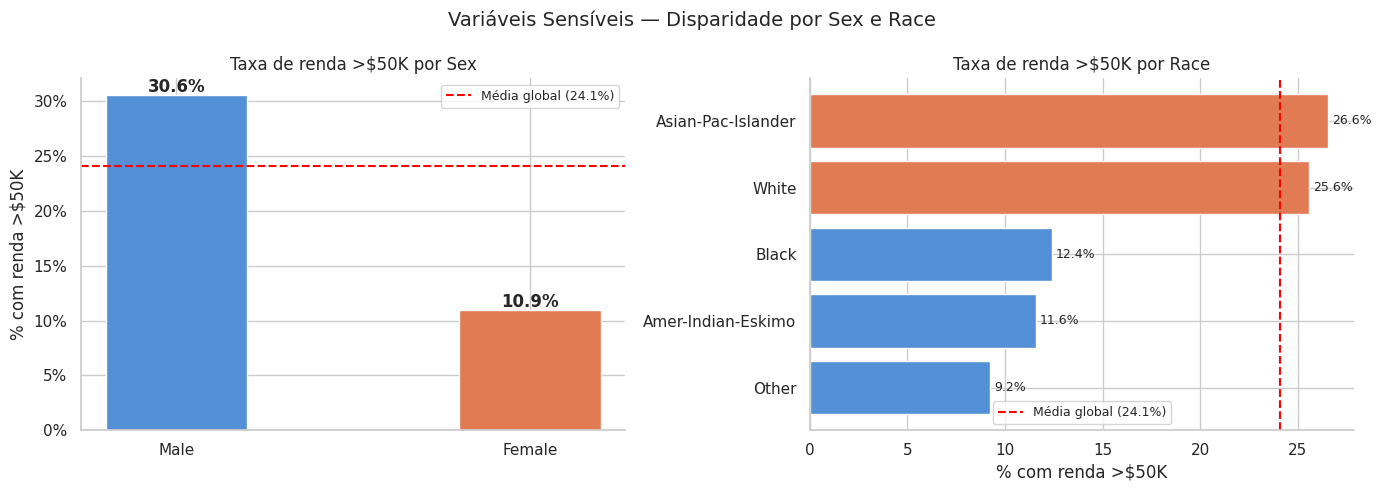

Taxa de >50K por sex:
sex
Male      30.6
Female    10.9

Gap de gênero: 19.6 pontos percentuais

Contagem de registros por sex:
sex
Male      21790
Female    10771

Taxa de >50K por race:
race
Asian-Pac-Islander    26.6
White                 25.6
Black                 12.4
Amer-Indian-Eskimo    11.6
Other                  9.2

Gap racial (maior - menor): 17.3 pontos percentuais

Contagem de registros por race:
race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
global_rate = (df["salary"] == ">50K").mean() * 100

# Sex
income_sex = (
    df.groupby("sex")["salary"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .sort_values(ascending=False)
)
bars_sex = axes[0].bar(
    income_sex.index,
    income_sex.values,
    color=["#5490D6", "#E07B54"],
    edgecolor="white",
    width=0.4,
)
axes[0].axhline(
    y=global_rate,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média global ({global_rate:.1f}%)",
)
axes[0].set_title("Taxa de renda >$50K por Sex", fontsize=12)
axes[0].set_ylabel("% com renda >$50K")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[0].legend(fontsize=9)
for bar in bars_sex:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        f"{h:.1f}%",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

# Race
income_race = (
    df.groupby("race")["salary"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .sort_values(ascending=True)
)
bar_colors_r = ["#E07B54" if v > global_rate else "#5490D6" for v in income_race.values]
bars_race = axes[1].barh(
    income_race.index, income_race.values, color=bar_colors_r, edgecolor="white"
)
axes[1].axvline(
    x=global_rate,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média global ({global_rate:.1f}%)",
)
axes[1].set_title("Taxa de renda >$50K por Race", fontsize=12)
axes[1].set_xlabel("% com renda >$50K")
axes[1].legend(fontsize=9)
for bar, val in zip(bars_race, income_race.values):
    axes[1].text(
        val + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )

fig.suptitle("Variáveis Sensíveis — Disparidade por Sex e Race", fontsize=14)
plt.tight_layout()
plt.show()

print("Taxa de >50K por sex:")
print(income_sex.round(1).to_string())
print(f"\nGap de gênero: {income_sex.max() - income_sex.min():.1f} pontos percentuais")
print("\nContagem de registros por sex:")
print(df["sex"].value_counts().to_string())
print("\nTaxa de >50K por race:")
print(income_race.sort_values(ascending=False).round(1).to_string())
print(
    f"\nGap racial (maior - menor): {income_race.max() - income_race.min():.1f} pontos percentuais"
)
print("\nContagem de registros por race:")
print(df["race"].value_counts().to_string())

### Conclusão — Variáveis Sensíveis (Fairness)

> **Existem disparidades significativas nos dados de treinamento.** Isso não significa que o modelo as causou — elas estão no ground-truth.

**Achados principais:**

**Sex:**
- `Male` tem taxa de `>50K` de ~30%, contra ~10–11% para `Female` — **gap de ~20 pontos percentuais**.
- O dataset tem muito mais registros de homens (~67%) do que mulheres (~33%).
- Um modelo treinado nesse dado tenderá a associar sexo masculino com renda alta — não porque o modelo é tendencioso, mas porque os dados refletem desigualdades históricas de 1994.

**Race:**
- `White` e `Asian-Pac-Islander` têm taxas de `>50K` acima da média global.
- `Black`, `Amer-Indian-Eskimo` e `Other` ficam abaixo — com `Other` em torno de 10–14%.
- Grupos como `Amer-Indian-Eskimo` têm **muito poucos registros**, o que torna métricas de slice instáveis e pouco confiáveis para esse subgrupo.

**Implicação para o modelo:**

- A **validação por slice** em `sex` e `race` é obrigatória: o F1 global pode ser bom enquanto o modelo falha sistematicamente para grupos específicos.
- É possível que o modelo aprenda `marital-status` e `relationship` como proxies de `sex` (ex: `Husband` implica `Male`) — o que transfere indiretamente o viés de gênero para o modelo mesmo sem usar `sex` como feature.

---
## 7. Conclusões, Decisões de Modelagem e Validação por Slice

### 7.1 O que é Validação por Slice?

**Slice** é um subgrupo do dataset definido por um valor específico de uma feature categórica.

Por exemplo:
- Slice `education = Doctorate` → todas as linhas onde education é Doctorate
- Slice `sex = Female` → todas as linhas onde sex é Female
- Slice `race = Black` → todas as linhas onde race é Black

**Validação por slice** significa calcular as métricas do modelo (precision, recall, F1) **separadamente para cada valor de uma feature**, em vez de calcular apenas a métrica global.

---

**Por que isso importa?**

Imagine que o seu modelo tem F1 = 0.82 no conjunto de teste. Isso parece bom. Mas:

| Slice | F1 |
|---|---|
| education = Doctorate | 0.91 |
| education = Bachelors | 0.84 |
| education = HS-grad | 0.75 |
| education = Preschool | 0.41 ← problema! |

O modelo funciona bem para os grupos com muitos dados (maioria do dataset), mas falha no grupo `Preschool` porque teve poucos exemplos para aprender. A **métrica global mascara essa falha**.

Em contextos de fairness, o mesmo acontece com `sex` e `race`: o modelo pode ter F1 = 0.82 globalmente mas F1 = 0.55 para `sex = Female` ou `race = Black`.

---

**Neste projeto, geraremos o arquivo `model/slice_output.txt`** com as métricas (precision, recall, F1) calculadas para cada valor de cada feature categórica. Isso permite monitorar:

1. Quais slices têm performance abaixo da média → candidatos a investigação
2. Quais slices têm poucos registros → métricas instáveis que precisam de contexto
3. Quais variáveis sensíveis expõem disparidades → riscos de fairness

---

### 7.2 Síntese das Hipóteses

| Hipótese | Status | Achado Principal | Decisão de Modelagem |
|---|---|---|---|
| H1 — Education | ✅ Confirmada | Relação monotônica clara: Doctorate > Masters > Bachelors | Incluir `education-num` (ordinal) + `education` (categórica) |
| H2 — Capital Gain | ✅ Confirmada | Efeito quase binário: qualquer valor > 0 triplica a chance de >50K | Incluir `capital-gain` + investigar `capital-loss` |
| H3 — Marital Status | ✅ Confirmada | Married-civ-spouse com taxa 3x acima das demais | Incluir `marital-status`; monitorar slice para não criar proxy de `sex` |
| H4 — Hours/week | ✅ Confirmada (contrarian) | Correlação fraca isolada (~0.23); efeito real é mediado por `occupation` | Incluir ambas as features; monitorar interação no slice |
| Fairness — Sex/Race | ⚠️ Risco identificado | Gap de 20pp entre sexos; grupos raciais sub-representados | Validação obrigatória por slice de `sex` e `race` após treino |

---

### 7.3 Decisões de Modelagem baseadas na EDA

**1. Features a incluir no modelo baseline:**
- Todas as 14 features disponíveis — nenhuma é irrelevante dado o que vimos
- `education-num` já é a versão numérica de `education` — incluir ambas ou escolher uma (encoding)
- `fnlwgt` é peso amostral do censo — valor preditivo baixo; avaliar exclusão

**2. Valores ausentes:**
- `workclass`, `occupation` e `native-country` têm valores `?` codificados
- Estratégia: tratar `?` como uma categoria separada `"Unknown"` — não descartar as linhas

**3. Métrica principal:**
- **F1-score** sobre a classe `>50K` (pos_label)
- Monitorar também `precision` e `recall` separadamente — dependendo do uso, poderíamos querer mais de um ou de outro

**4. Validação por slice obrigatória:**
- Calcular métricas para cada valor de: `education`, `sex`, `race`, `occupation`, `marital-status`, `native-country`
- Salvar em `model/slice_output.txt` para rastreabilidade
- Documentar no `model_card.md` os slices com performance abaixo de 0.6 de F1

**5. Modelo baseline:**
- `RandomForestClassifier(random_state=42)` — sem tuning inicial
- Objetivo: estabelecer um baseline funcional e validar o pipeline ponta a ponta antes de qualquer otimização